> ⚠️ **Engine v2: backtest KHÔNG còn look-ahead cùng ngày (`src/backtest.py`).** Output cũ đã được xóa vì tính bằng engine có look-ahead cùng ngày (bản cũ còn nguyên output: `notebooks/legacy_v1_outputs/`). **Chạy lại notebook này** để có số liệu mới; tổng hợp cả 3 chiến lược nằm ở `06_engine_v2_rerun.ipynb`.


# Backtest dùng THẲNG Single Factor (Momentum_6_1)

**Bối cảnh:** Lần chạy lại gần nhất (xem `reports/research_note.md` mục 5)
cho kết quả:

```
Method                                            Mean IC   IC-IR
Best single factor (Momentum_6_1)                  0.0501    NaN
IC-Weighted composite (dùng trong launcher.py)     0.0466  0.1606
Ridge (all features)                               0.0171  0.0637
XGBoost (all features)                             0.0373  0.1721
```

**Momentum_6_1 đứng riêng có Mean IC cao nhất — vượt cả composite IC-Weighted
đang dùng trong `launcher.py`.** Notebook này backtest THẲNG bằng
Momentum_6_1 (không composite, không ML), có transaction cost + slippage
(giữ nguyên 0.23%/lệnh), để trả lời câu hỏi: nếu IC cao hơn có tự động dịch
thành Sharpe cao hơn sau backtest thực tế hay không — và có nên thay
`comp_score` trong `launcher.py` bằng thẳng `mom_6_1` hay không.

⚠️ Notebook dùng lại NGUYÊN VẸN `backtest_with_exits()` từ `src/backtest.py`
— chỉ khác tham số signal đầu vào (rank của `mom_6_1` thay vì `comp_score`).
Toàn bộ entry/exit rules, cost model giữ nguyên để so sánh công bằng.


In [1]:
## -*- coding: utf-8 -*-
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_loader import VN30_UNIVERSE, load_ohlcv, filter_by_coverage
from src.momentum_factors import momentum_6_1, momentum_12_1
from src.feature_engineering import assemble_dataset, cross_sectional_rank
from src.ic_analysis import single_factor_ic, composite_score_ic
from src.strategy import composite_score, normalize_ic_weights
from src.backtest import backtest_with_exits, invested_returns, port_metrics, trade_statistics, calmar_ratio, TOTAL_COST_RATE
from src.risk import equal_weight_benchmark, compare_strategies

pd.set_option("display.float_format", lambda x: f"{x:.4f}")


## 1. Tải dữ liệu + build factors (giống Ngày 19-20)

In [2]:
START, END = "2022-01-01", "2025-12-31"

ohlcv = load_ohlcv(VN30_UNIVERSE, START, END, fields=("close", "open", "volume"))
price_df, volume_df = ohlcv["close"], ohlcv["volume"]
price_df, dropped = filter_by_coverage(price_df)
volume_df = volume_df[price_df.columns]
print(f"Universe: {len(price_df.columns)} mã (loại {dropped})")


[1/30] Loading ACB...


[2/30] Loading BID...
[3/30] Loading BSR...
[4/30] Loading CTG...
[5/30] Loading FPT...
[6/30] Loading GAS...
[7/30] Loading GVR...
[8/30] Loading HDB...
[9/30] Loading HPG...
[10/30] Loading LPB...
[11/30] Loading MBB...
[12/30] Loading MCH...


[13/30] Loading MSN...
[14/30] Loading MWG...
[15/30] Loading SAB...
[16/30] Loading SHB...
[17/30] Loading SSB...
[18/30] Loading SSI...
⏳ Nghỉ 65s để tránh rate limit...
[19/30] Loading STB...
[20/30] Loading TCB...
[21/30] Loading TCX...
[22/30] Loading VCB...
[23/30] Loading VHM...
[24/30] Loading VIB...
[25/30] Loading VIC...
[26/30] Loading VJC...
[27/30] Loading VNM...
[28/30] Loading VPB...
[29/30] Loading VPL...
[30/30] Loading VRE...



✅ Đã tải: 30/30 mã
Universe: 28 mã (loại ['TCX', 'VPL'])


In [3]:
returns_df = price_df.pct_change(fill_method=None)
vol_20 = returns_df.rolling(20).std()
vol_120 = returns_df.rolling(120).std()
vol_spike = vol_20 / vol_120

mom_6_1 = momentum_6_1(price_df)
mom_12_1 = momentum_12_1(price_df)
TARGET_VOL = 0.15 / np.sqrt(252)
ts_mom = np.sign(mom_12_1) * (TARGET_VOL / vol_20.replace(0, np.nan))

raw_factors = {
    "Momentum_6_1": mom_6_1, "Momentum_12_1": mom_12_1,
    "Volume_Ratio": volume_df / volume_df.rolling(20).mean(), "TS_Momentum": ts_mom,
}
feature_cols = list(raw_factors.keys())

dataset = assemble_dataset(raw_factors, price_df, n_fwd=5, label_type="regression")
sf_ic = single_factor_ic(dataset, feature_cols, n_splits=5, embargo=5)
print("=== Mean IC từng factor (Purged K-Fold OOS) ===")
print(sf_ic.round(4))

ic_weights = normalize_ic_weights(sf_ic)
ranked_factors = {name: cross_sectional_rank(f) for name, f in raw_factors.items()}
comp_score = composite_score(ranked_factors, ic_weights)

comp_eval = composite_score_ic(dataset, feature_cols, ic_weights, n_splits=5, embargo=5)
print(f"\nIC-Weighted composite Mean IC: {comp_eval['Mean IC']:.4f}")
print(f"Momentum_6_1 (đứng riêng) Mean IC: {sf_ic['Momentum_6_1']:.4f}")

if sf_ic["Momentum_6_1"] > comp_eval["Mean IC"]:
    print("\n⚠️ Momentum_6_1 đứng riêng có IC CAO HƠN composite — đây là lý do notebook này tồn tại.")


=== Mean IC từng factor (Purged K-Fold OOS) ===
Momentum_6_1    0.0525
Momentum_12_1   0.0441
TS_Momentum     0.0335
Volume_Ratio    0.0058
Name: Mean IC, dtype: float64

IC-Weighted composite Mean IC: 0.0570
Momentum_6_1 (đứng riêng) Mean IC: 0.0525


## 2. Signal Single Factor — rank thuần của Momentum_6_1

Không kết hợp với factor nào khác, không train model nào — chỉ cross-sectional
rank của `momentum_6_1` mỗi ngày, dùng trực tiếp làm signal cho
`backtest_with_exits()` (thay thế vị trí `comp_score`).

In [4]:
single_factor_signal = ranked_factors["Momentum_6_1"]  # đã rank cross-sectional, cùng thang đo [0,1] như comp_score
print(f"Single factor signal shape: {single_factor_signal.shape}")
print(f"Sample (ngày cuối):\n{single_factor_signal.iloc[-1].dropna().sort_values(ascending=False).head()}")


Single factor signal shape: (997, 28)
Sample (ngày cuối):
VIC   1.0000
VJC   0.9643
MCH   0.9286
VPB   0.8929
SHB   0.8571
Name: 2025-12-31 07:00:00, dtype: float64


## 3. Backtest — Single Factor vs Composite (CÓ transaction cost + slippage)

Cả 2 backtest dùng CHUNG entry/exit rules, cùng cost_rate — khác biệt DUY
NHẤT là signal đầu vào (`single_factor_signal` vs `comp_score`).

In [5]:
port_single, trade_single = backtest_with_exits(
    price_df, single_factor_signal, vol_spike, mom_6_1,
    stop_loss_pct=0.08, trail_pct=0.12, vol_exit_thr=3.0, vol_reduce_thr=2.0,
    top_entry_rank=0.65, signal_exit_rank=0.40, max_positions=10, rebal_freq=5,
    cost_rate=TOTAL_COST_RATE,
)
ret_single = port_single["port_return"]
m_single = port_metrics(invested_returns(port_single))
m_single["Calmar"] = calmar_ratio(m_single)

print("=== Single Factor (Momentum_6_1) — CÓ transaction cost + slippage ===")
for k, v in m_single.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")


=== Single Factor (Momentum_6_1) — CÓ transaction cost + slippage ===
  Total Return: 1.6030
  Ann Return: 0.3210
  Ann Vol: 0.2060
  Sharpe: 1.5585
  Max DD: -0.2022
  Calmar: 1.5872


In [6]:
port_composite, trade_composite = backtest_with_exits(
    price_df, comp_score, vol_spike, mom_6_1,
    stop_loss_pct=0.08, trail_pct=0.12, vol_exit_thr=3.0, vol_reduce_thr=2.0,
    top_entry_rank=0.65, signal_exit_rank=0.40, max_positions=10, rebal_freq=5,
    cost_rate=TOTAL_COST_RATE,
)
ret_composite = port_composite["port_return"]
m_composite = port_metrics(invested_returns(port_composite))
m_composite["Calmar"] = calmar_ratio(m_composite)

print("=== IC-Weighted Composite (dùng trong launcher.py hiện tại) — CÓ cost ===")
for k, v in m_composite.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")


=== IC-Weighted Composite (dùng trong launcher.py hiện tại) — CÓ cost ===
  Total Return: 1.6133
  Ann Return: 0.3864
  Ann Vol: 0.2063
  Sharpe: 1.8731
  Max DD: -0.1867
  Calmar: 2.0697


## 4. So sánh 3 chiều: Single Factor vs Composite vs 1/N Benchmark

In [7]:
ew_ret = equal_weight_benchmark(price_df)

strategies = {
    "Single Factor (Momentum_6_1, CÓ cost)": invested_returns(port_single),
    "IC-Weighted Composite (CÓ cost)": invested_returns(port_composite),
    "1/N Equal-Weight": ew_ret,
}
cmp_df = compare_strategies(strategies)
print(cmp_df.round(4).to_string())

sharpe_single = cmp_df.loc["Single Factor (Momentum_6_1, CÓ cost)", "Sharpe"]
sharpe_composite = cmp_df.loc["IC-Weighted Composite (CÓ cost)", "Sharpe"]
sharpe_ew = cmp_df.loc["1/N Equal-Weight", "Sharpe"]

print(f"\nSharpe Single Factor:  {sharpe_single:.4f}")
print(f"Sharpe Composite:      {sharpe_composite:.4f}")
print(f"Sharpe 1/N:            {sharpe_ew:.4f}")

if sharpe_single > sharpe_composite:
    print(f"\n✅ Single Factor THẮNG Composite sau backtest (chênh {sharpe_single - sharpe_composite:.4f}) "
          f"— khớp với IC cao hơn đo được ở Ngày 19.")
else:
    print(f"\n⚠️ Single Factor CÓ IC cao hơn nhưng THUA Composite sau backtest (chênh "
          f"{sharpe_composite - sharpe_single:.4f}) — IC cao không tự động nghĩa là Sharpe cao hơn, "
          f"vì backtest còn phụ thuộc entry/exit rules, turnover, và cách signal tương tác với "
          f"vol_spike/mom_6 trong PositionManager (không chỉ riêng chất lượng xếp hạng).")


                                       Total Return  Ann Return  Ann Vol  Sharpe  Max DD  Calmar  Sharpe SE
Single Factor (Momentum_6_1, CÓ cost)        1.4031      0.3474   0.2056  1.6894 -0.2022  1.7177     0.5846
IC-Weighted Composite (CÓ cost)              1.6133      0.3864   0.2063  1.8731 -0.1867  2.0697     0.5848
1/N Equal-Weight                             1.0134      0.2687   0.1798  1.4944 -0.1681  1.5986     0.5843

Sharpe Single Factor:  1.6894
Sharpe Composite:      1.8731
Sharpe 1/N:            1.4944

⚠️ Single Factor CÓ IC cao hơn nhưng THUA Composite sau backtest (chênh 0.1836) — IC cao không tự động nghĩa là Sharpe cao hơn, vì backtest còn phụ thuộc entry/exit rules, turnover, và cách signal tương tác với vol_spike/mom_6 trong PositionManager (không chỉ riêng chất lượng xếp hạng).


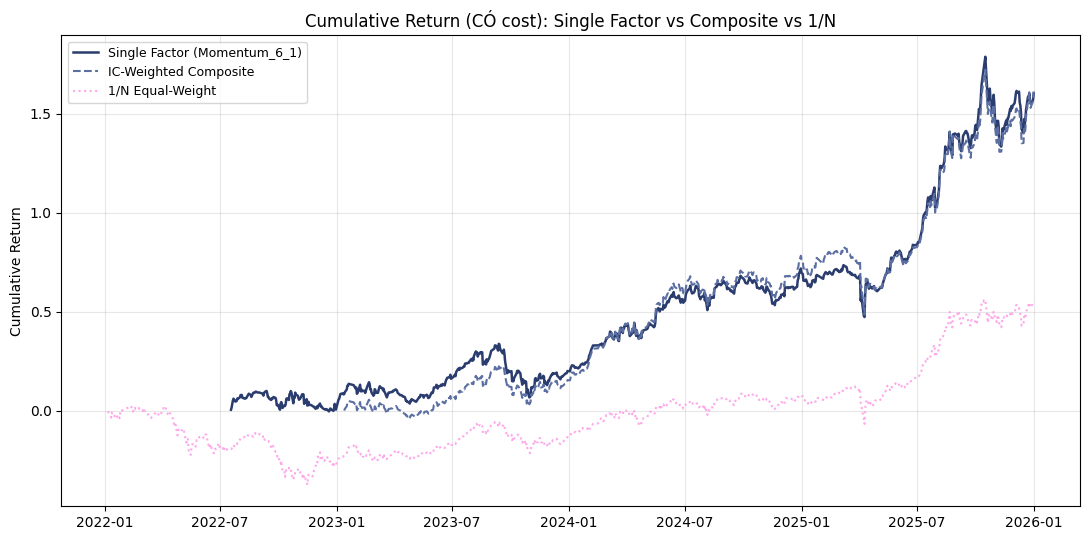

✅ Đã lưu: reports/day21_single_factor_vs_composite.png


In [8]:
fig, ax = plt.subplots(figsize=(11, 5.5))

cum_single = (1 + invested_returns(port_single)).cumprod() - 1
cum_composite = (1 + invested_returns(port_composite)).cumprod() - 1
cum_ew = (1 + ew_ret).cumprod() - 1

ax.plot(cum_single.index, cum_single.values, label="Single Factor (Momentum_6_1)", color="#2b3d6f", linewidth=1.8)
ax.plot(cum_composite.index, cum_composite.values, label="IC-Weighted Composite", color="#5b6fa2", linewidth=1.5, linestyle="--")
ax.plot(cum_ew.index, cum_ew.values, label="1/N Equal-Weight", color="#fea7e9", linewidth=1.5, linestyle=":")
ax.set_title("Cumulative Return (CÓ cost): Single Factor vs Composite vs 1/N")
ax.set_ylabel("Cumulative Return")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/day21_single_factor_vs_composite.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Đã lưu: reports/day21_single_factor_vs_composite.png")


## 5. Turnover & Trade Statistics — Single Factor có giao dịch nhiều hơn/ít hơn?

In [9]:
stats_single = trade_statistics(trade_single)
stats_composite = trade_statistics(trade_composite)

print("=== Trade statistics: Single Factor vs Composite ===")
compare_trades = pd.DataFrame({
    "Single Factor": {
        "n_buys": stats_single.get("n_buys", 0), "n_sells": stats_single.get("n_sells", 0),
        "win_rate": stats_single.get("win_rate", np.nan),
        "avg_hold_days": stats_single.get("avg_hold_days", np.nan),
        "total_cost_paid": port_single["cost"].sum(),
    },
    "Composite": {
        "n_buys": stats_composite.get("n_buys", 0), "n_sells": stats_composite.get("n_sells", 0),
        "win_rate": stats_composite.get("win_rate", np.nan),
        "avg_hold_days": stats_composite.get("avg_hold_days", np.nan),
        "total_cost_paid": port_composite["cost"].sum(),
    },
}).T
print(compare_trades)

print("\n=== Exit breakdown ===")
print("Single Factor:", stats_single.get("exit_breakdown", {}))
print("Composite:    ", stats_composite.get("exit_breakdown", {}))


=== Trade statistics: Single Factor vs Composite ===
                n_buys  n_sells  win_rate  avg_hold_days  total_cost_paid
Single Factor 209.0000 203.0000    0.5714        51.3448           0.1220
Composite     191.0000 187.0000    0.5561        51.7433           0.0947

=== Exit breakdown ===
Single Factor: {'MOM_FLIP': 77, 'HARD_STOP': 46, 'TRAILING_STOP': 41, 'SIGNAL_EXIT': 35, 'VOL_REDUCE': 4}
Composite:     {'MOM_FLIP': 78, 'TRAILING_STOP': 42, 'HARD_STOP': 38, 'SIGNAL_EXIT': 23, 'VOL_REDUCE': 6}


## 6. Kết luận Ngày 21 — Nên dùng Single Factor hay Composite trong launcher.py?

So sánh trực tiếp Sharpe CÓ COST giữa 2 phương án — đây là câu trả lời thực
dụng, không chỉ dựa trên IC đơn thuần (IC đo khả năng xếp hạng, không đo
trực tiếp hiệu suất backtest có entry/exit rules cụ thể và cost).

⚠️ **Quan trọng**: nếu kết luận là "nên đổi sang single factor", cần sửa
`launcher.py` (dòng gọi `composite_score(...)` → thay bằng
`cross_sectional_rank(raw_factors["Momentum_6_1"])`) và cập nhật lại
`reports/research_note.md` + `README.md` cho nhất quán — xem output cell
trên để quyết định.

In [10]:
print("=" * 65)
print("TÓM TẮT NGÀY 21")
print("=" * 65)
print(f"Mean IC — Single Factor:  {sf_ic['Momentum_6_1']:.4f}")
print(f"Mean IC — Composite:      {comp_eval['Mean IC']:.4f}")
print(f"\nSharpe (có cost) — Single Factor:  {sharpe_single:.4f}")
print(f"Sharpe (có cost) — Composite:       {sharpe_composite:.4f}")
print(f"Sharpe (có cost) — 1/N:             {sharpe_ew:.4f}")

winner = "Single Factor" if sharpe_single > sharpe_composite else "Composite"
print(f"\n🏆 Phương án Sharpe cao hơn (có cost): {winner}")
print(f"   → Khuyến nghị: {'đổi launcher.py sang dùng thẳng Momentum_6_1' if winner == 'Single Factor' else 'giữ nguyên composite trong launcher.py'}")


TÓM TẮT NGÀY 21
Mean IC — Single Factor:  0.0525
Mean IC — Composite:      0.0570

Sharpe (có cost) — Single Factor:  1.6894
Sharpe (có cost) — Composite:       1.8731
Sharpe (có cost) — 1/N:             1.4944

🏆 Phương án Sharpe cao hơn (có cost): Composite
   → Khuyến nghị: giữ nguyên composite trong launcher.py
